In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Credit_Card_O = pd.read_csv('Credit card transactions')
Credit_Card_O

,Index,City,Date,Card Type,Exp Type,Gender,Amount
0,1,"Delhi, India",29-Oct-14,Gold,Bills,F,82475
1,2,"Greater Mumbai, India",22-Aug-14,Platinum,Bills,F,32555
2,3,"Bengaluru, India",27-Aug-14,Silver,Bills,F,101738
3,4,"Greater Mumbai, India",12-Apr-14,Signature,Bills,F,123424
4,5,"Bengaluru, India",5-May-15,Gold,Bills,F,171574
...,...,...,...,...,...,...,...
26047,26048,"Kolkata, India",22-Jun-14,Silver,Travel,F,128191
26048,26049,"Pune, India",3-Aug-14,Signature,Travel,M,246316
26049,26050,"Hyderabad, India",16-Jan-15,Silver,Travel,M,265019
26050,26051,"Kanpur, India",14-Sep-14,Silver,Travel,M,88174


In [ ]:
print(Credit_Card_O['Gender'].value_counts())
print("\nUnique values:", Credit_Card_O['Gender'].unique())

Gender
F    13680
M    12372
Name: count, dtype: int64

Unique values: ['F' 'M']


In [ ]:
print(Credit_Card_O['Exp Type'].value_counts())
print("\nUnique values:", Credit_Card_O['Exp Type'].unique())

Exp Type
Food             5463
Fuel             5257
Bills            5078
Entertainment    4762
Grocery          4754
Travel            738
Name: count, dtype: int64

Unique values: ['Bills' 'Food' 'Entertainment' 'Grocery' 'Fuel' 'Travel']


In [ ]:
Credit_Card_O.isnull().sum()

,0
Index,0
City,0
Date,0
Card Type,0
Exp Type,0
Gender,0
Amount,0


In [ ]:
Credit_Card_O.duplicated().sum()

np.int64(0)

In [ ]:
print("Shape:", Credit_Card_O.shape)
print("\nColumns:", Credit_Card_O.columns.tolist())
print("\nDtypes:\n", Credit_Card_O.dtypes)
print("\nExp Type:\n", Credit_Card_O['Exp Type'].value_counts())
print("\nCard Type:\n", Credit_Card_O['Card Type'].value_counts())
print("\nGender:\n", Credit_Card_O['Gender'].value_counts())
print("\nCity (Top 10):\n", Credit_Card_O['City'].value_counts().head(10))
print("\nAmount Stats:\n", Credit_Card_O['Amount'].describe())

Shape: (26052, 7)

Columns: ['Index', 'City', 'Date', 'Card Type', 'Exp Type', 'Gender', 'Amount']

Dtypes:
 Index         int64
City         object
Date         object
Card Type    object
Exp Type     object
Gender       object
Amount        int64
dtype: object

Exp Type:
 Exp Type
Food             5463
Fuel             5257
Bills            5078
Entertainment    4762
Grocery          4754
Travel            738
Name: count, dtype: int64

Card Type:
 Card Type
Silver       6840
Signature    6447
Platinum     6398
Gold         6367
Name: count, dtype: int64

Gender:
 Gender
F    13680
M    12372
Name: count, dtype: int64

City (Top 10):
 City
Bengaluru, India         3552
Greater Mumbai, India    3493
Ahmedabad, India         3491
Delhi, India             3482
Hyderabad, India          784
Chennai, India            774
Kolkata, India            773
Kanpur, India             764
Lucknow, India            759
Jaipur, India             752
Name: count, dtype: int64

Amount Stats:
 count   

In [ ]:
Credit_Card_O['Date'] = pd.to_datetime(Credit_Card_O['Date'])
Credit_Card_O['Month'] = Credit_Card_O['Date'].dt.month_name()
Credit_Card_O['Year'] = Credit_Card_O['Date'].dt.year
Credit_Card_O['Month_Num'] = Credit_Card_O['Date'].dt.month

/tmp/ipykernel_298/773355179.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Credit_Card_O['Date'] = pd.to_datetime(Credit_Card_O['Date'])


In [ ]:
Credit_Card_O

,Index,City,Date,Card Type,Exp Type,Gender,Amount,Month,Year,Month_Num
0,1,"Delhi, India",2014-10-29,Gold,Bills,F,82475,October,2014,10
1,2,"Greater Mumbai, India",2014-08-22,Platinum,Bills,F,32555,August,2014,8
2,3,"Bengaluru, India",2014-08-27,Silver,Bills,F,101738,August,2014,8
3,4,"Greater Mumbai, India",2014-04-12,Signature,Bills,F,123424,April,2014,4
4,5,"Bengaluru, India",2015-05-05,Gold,Bills,F,171574,May,2015,5
...,...,...,...,...,...,...,...,...,...,...
26047,26048,"Kolkata, India",2014-06-22,Silver,Travel,F,128191,June,2014,6
26048,26049,"Pune, India",2014-08-03,Signature,Travel,M,246316,August,2014,8
26049,26050,"Hyderabad, India",2015-01-16,Silver,Travel,M,265019,January,2015,1
26050,26051,"Kanpur, India",2014-09-14,Silver,Travel,M,88174,September,2014,9


## Spend by Exp Type

In [ ]:
# Total spend by Exp Type
exp_spend = Credit_Card_O.groupby('Exp Type')['Amount'].sum().sort_values(ascending=False).reset_index()
exp_spend['Amount_Crore'] = (exp_spend['Amount'] / 10000000).round(2)

exp_spend

,Exp Type,Amount,Amount_Crore
0,Bills,907072473,90.71
1,Food,824724009,82.47
2,Fuel,789135821,78.91
3,Entertainment,726437536,72.64
4,Grocery,718207923,71.82
5,Travel,109255611,10.93


In [ ]:
# Average Spend

print("Avg by Exp Type:")
print(Credit_Card_O.groupby('Exp Type')['Amount'].mean().round(2).sort_values(ascending=False))

Avg by Exp Type:
Exp Type
Bills            178627.90
Entertainment    152548.83
Grocery          151074.45
Food             150965.41
Fuel             150111.44
Travel           148042.83
Name: Amount, dtype: float64


/tmp/ipykernel_298/4101270871.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=exp_spend, x='Exp Type', y='Amount_Crore', palette='Blues_d')


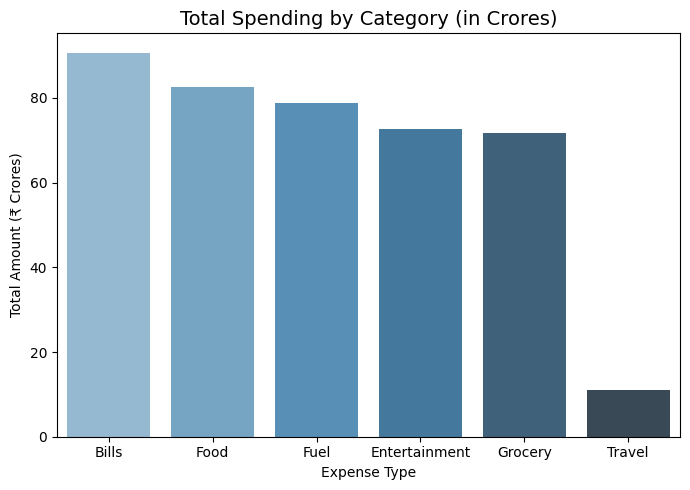

In [ ]:
# Plot
plt.figure(figsize=(7, 5))
sns.barplot(data=exp_spend, x='Exp Type', y='Amount_Crore', palette='Blues_d')
plt.title('Total Spending by Category (in Crores)', fontsize=14)
plt.xlabel('Expense Type')
plt.ylabel('Total Amount (₹ Crores)')
plt.tight_layout()
plt.show()

**Spend by Exp Type**

Food leads in both transaction count (5,463) and likely total spend

Travel is the outlier — only 738 transactions, will likely be the lowest spend category

Bills, Fuel close behind Food — essentials dominate spending

## Spend by Card Type

In [ ]:
# Spending by Card Type
card_spend = Credit_Card_O.groupby('Card Type')['Amount'].sum().sort_values(ascending=False).reset_index()
card_spend['Amount_Crore'] = (card_spend['Amount'] / 10000000).round(2)
print(f'Spend by Card Type: \n', card_spend)

Spend by Card Type: 
    Card Type      Amount  Amount_Crore
0     Silver  1069613713        106.96
1  Signature  1013041105        101.30
2   Platinum  1007639019        100.76
3       Gold   984539536         98.45


In [ ]:
# Average Spend by Card Type

print("\nAvg by Card Type:")
print(Credit_Card_O.groupby('Card Type')['Amount'].mean().round(2).sort_values(ascending=False))


Avg by Card Type:
Card Type
Platinum     157492.81
Signature    157133.72
Silver       156376.27
Gold         154631.62
Name: Amount, dtype: float64


/tmp/ipykernel_298/3773664443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=card_spend, x='Card Type', y='Amount_Crore', palette='Blues_d')


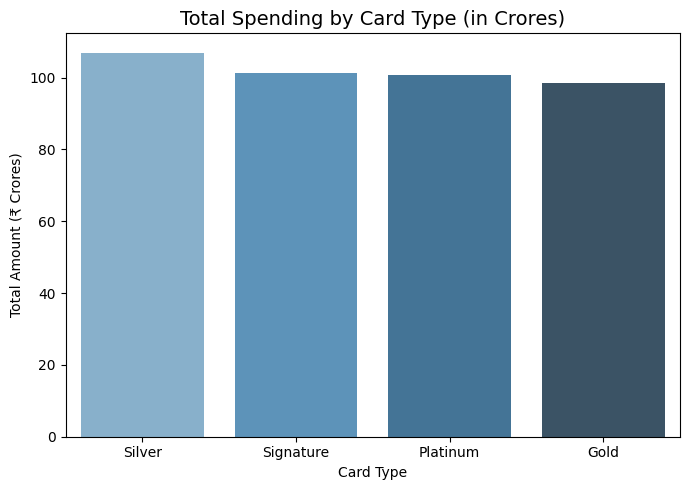

In [ ]:
# Plot
plt.figure(figsize=(7, 5))
sns.barplot(data=card_spend, x='Card Type', y='Amount_Crore', palette='Blues_d')
plt.title('Total Spending by Card Type (in Crores)', fontsize=14)
plt.xlabel('Card Type')
plt.ylabel('Total Amount (₹ Crores)')
plt.tight_layout()
plt.show()

**Spend by Card Type**

Distribution is nearly equal across all 4 card types (~6,400–6,840 each)

Expect Silver to edge out slightly in total spend due to higher transaction count

Good finding: no single card type dominates — balanced portfolio

## Spend by Gender

In [ ]:
# Spending by Gender
gender_spend = Credit_Card_O.groupby('Gender')['Amount'].sum().sort_values(ascending=False).reset_index()
gender_spend['Amount Crore'] = (gender_spend['Amount'] / 10000000).round(2)
gender_spend

,Gender,Amount,Amount Crore
0,F,2205311030,220.53
1,M,1869522343,186.95


In [ ]:
# Average Spend by Gender
print(Credit_Card_O.groupby('Gender')['Amount'].mean().round(2))

Gender
F    161206.95
M    151109.15
Name: Amount, dtype: float64


/tmp/ipykernel_298/3842891559.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gender_spend, x='Gender', y='Amount Crore', palette='Blues_d')


<function matplotlib.pyplot.show(close=None, block=None)>

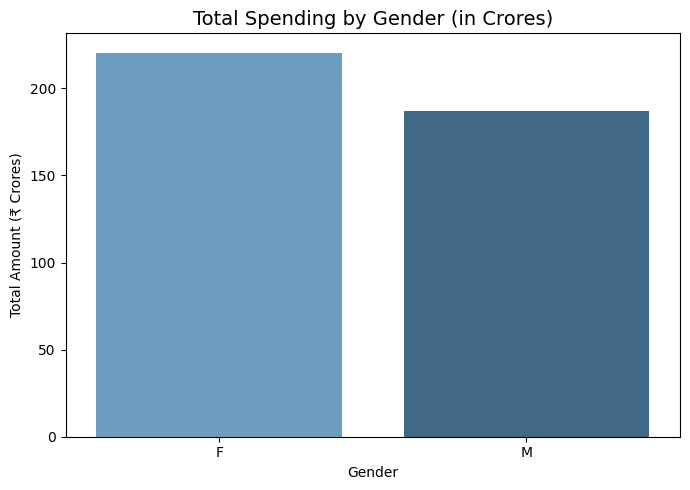

In [ ]:
# Plot
plt.figure(figsize=(7, 5))
sns.barplot(data=gender_spend, x='Gender', y='Amount Crore', palette='Blues_d')
plt.xlabel('Gender')
plt.ylabel('Total Amount (₹ Crores)')
plt.title('Total Spending by Gender (in Crores)', fontsize=14)
plt.tight_layout()
plt.show

**Spend by Gender**

Female cardholders (13,680) outnumber male (12,372) — ~10% more transactions

Expect total female spend to be proportionally higher

Average spend per transaction is the more meaningful metric to compare here

## Citywise Spend

In [ ]:
# City wise spend

City_Spend = Credit_Card_O.groupby('City')['Amount'].sum().sort_values(ascending=False).reset_index()
print(City_Spend)

                      City     Amount
0    Greater Mumbai, India  576751476
1         Bengaluru, India  572326739
2         Ahmedabad, India  567794310
3             Delhi, India  556929212
4           Kolkata, India  115466943
..                     ...        ...
981   Changanassery, India      30074
982           Tirur, India      26094
983        Bahraich, India      24253
984     Mahbubnagar, India      15458
985         Fazilka, India      14949

[986 rows x 2 columns]


/tmp/ipykernel_298/98693493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=City_Spend.head(10), x='City', y='Amount', palette='Blues_d')


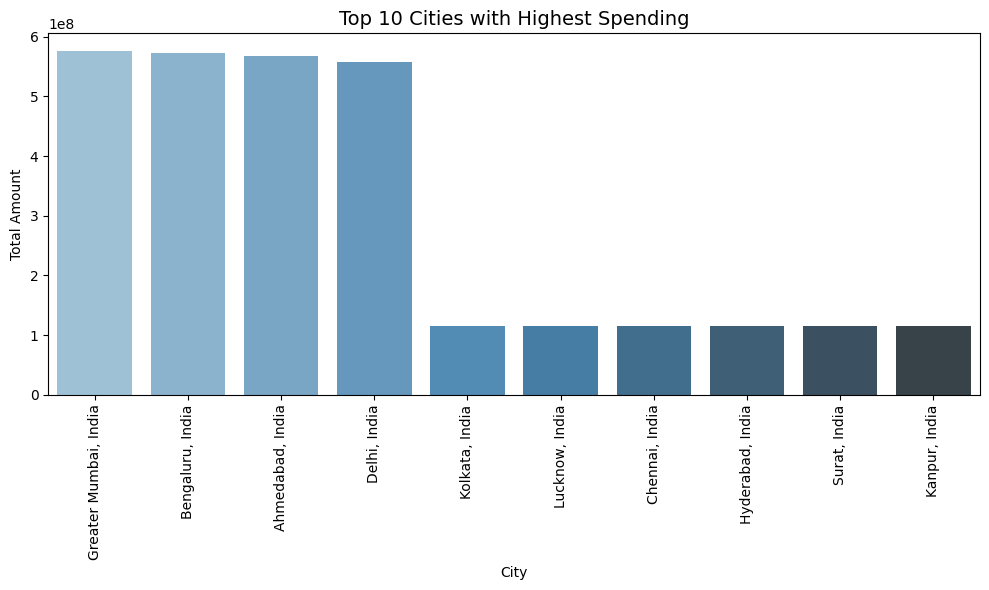

In [ ]:
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=City_Spend.head(10), x='City', y='Amount', palette='Blues_d')
plt.xlabel('City')
plt.ylabel('Total Amount')
plt.title('Top 10 Cities with Highest Spending', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**City Insights**

Top 4 Cities Dominate Completely

Mumbai, Bengaluru, Ahmedabad, Delhi are all tightly clustered between ₹55.7 Cr – ₹57.7 Cr

Then there's a massive cliff drop — Kolkata at ₹11.5 Cr is nearly 5x less than Delhi

This matches the transaction count pattern you saw earlier (top 4 had ~3,500 each, rest had ~750)

## Monthly Spend

In [ ]:
# Monthly Spend
Monthly_Spend = Credit_Card_O.groupby(['Year', 'Month_Num', 'Month'])['Amount'].sum().reset_index()
Monthly_Spend = Monthly_Spend.sort_values(['Year', 'Month_Num'])
print(Monthly_Spend)

    Year  Month_Num      Month     Amount
0   2013         10    October  207360092
1   2013         11   November  192015963
2   2013         12   December  214267829
3   2014          1    January  207650982
4   2014          2   February  189220180
5   2014          3      March  203233307
6   2014          4      April  208284732
7   2014          5        May  201762312
8   2014          6       June  191321039
9   2014          7       July  197981416
10  2014          8     August  218453126
11  2014          9  September  209561433
12  2014         10    October  212485915
13  2014         11   November  212092005
14  2014         12   December  202667586
15  2015          1    January  223558574
16  2015          2   February  194292444
17  2015          3      March  206821139
18  2015          4      April  208110002
19  2015          5        May  173693297


In [ ]:
print(f"Date Range: {Credit_Card_O['Date'].min()} to {Credit_Card_O['Date'].max()}")
print(f"Total Months: {Monthly_Spend.shape[0]}")

Date Range: 2013-10-04 00:00:00 to 2015-05-26 00:00:00
Total Months: 20


**Monthly Spending Pattern**

Most months hover between ₹19 Cr – ₹22 Cr

August 2014 is the highest so far at ₹21.8 Cr

May 2015 at ₹17.4 Cr looks like a dip — but it's an incomplete month (data cuts off May 26)

February dips consistently (2014: ₹18.9 Cr, 2015: ₹19.4 Cr) — fewer days effect

⚠️ Note: May 2015 should be excluded from trend analysis since it's a partial month.

## Distribution Analysis and Outlier Detection

In [ ]:
# Distribution stats
print(Credit_Card_O['Amount'].describe())

# Outlier check using IQR
Q1 = Credit_Card_O['Amount'].quantile(0.25)
Q3 = Credit_Card_O['Amount'].quantile(0.75)
IQR = Q3 - Q1
outliers = Credit_Card_O[(Credit_Card_O['Amount'] < Q1 - 1.5*IQR) |
                          (Credit_Card_O['Amount'] > Q3 + 1.5*IQR)]

print(f"\nTotal Outliers: {len(outliers)}")
print(f"Outlier %: {round(len(outliers)/len(Credit_Card_O)*100, 2)}%")
print(f"\nOutlier Amount Range: ₹{outliers['Amount'].min():,} – ₹{outliers['Amount'].max():,}")

count     26052.000000
mean     156411.537425
std      103063.254287
min        1005.000000
25%       77120.250000
50%      153106.500000
75%      228050.000000
max      998077.000000
Name: Amount, dtype: float64

Total Outliers: 229
Outlier %: 0.88%

Outlier Amount Range: ₹454,570 – ₹998,077


**Distribution is fairly normal**

Mean (₹1,56,411) and Median (₹1,53,106) are very close — minimal skew

50% of transactions fall between ₹77K – ₹2,28,050 (IQR range)

**Outliers — Very Clean Dataset**

Only 229 outliers out of 26,052 — just 0.88% — excellent data quality

Outlier threshold starts at ₹4,54,570 and goes up to ₹9,98,077

These are genuine high-value transactions, not data errors — safe to keep